## **【程式4.11】**

In [31]:
# 從tensorflow.keras.datasets模組中導入reuters資料集
from tensorflow.keras.datasets import reuters

# 載入reuters資料集，並將其分為訓練集和測試集
# num_words=10000 表示只保留訓練資料中最常出現的10000個單詞
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

In [32]:
# 計算 train_data 中元素的數量，即訓練集中的新聞文章數量，並將結果輸出。
len(train_data)

8982

In [33]:
# 計算 test_data 中元素的數量，即測試集中的新聞文章數量，並將結果輸出。
len(test_data)

2246

In [34]:
# 與4-1一樣，每個樣本都是一個整數串列
# 顯示第10筆訓練資料(Output的數值，代表單字的索引編號)
train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

## **【程式4.12】**

檢視某一筆資料，並將其解碼回單字

In [35]:
# 取得路透社資料集中的單字索引對應字典，鍵是單字，值是整數索引。
word_index = reuters.get_word_index()

# 將單字索引字典反轉，變成鍵是整數索引，值是單字的字典，方便將數字轉換回單字。
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# 將訓練資料中的第一篇新聞文章（train_data[0]）的數字序列解碼回可讀的單字串列
# 減去3是因為索引0、1、2是特殊保留字元，例如填充（padding）、序列開始（start of sequence）和未知單字（unknown）。如果索引減3後在反轉字典中找不到，則預設為'?'。
decoded_newswire = ' '.join([reverse_word_index.get(i - 3, '?') for i in train_data[0]])

# 輸出解碼後的新聞文章
print(decoded_newswire)

? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


In [36]:
# 顯示訓練集中第10筆新聞文章的類別標籤。
train_labels[10]

np.int64(3)

## **【程式4.13】**

In [37]:
# 匯入 NumPy 函式庫，並將其別名設定為 np，NumPy 用於高效地處理陣列和數值運算。
import numpy as np

# 定義一個名為 vectorize_sequences 的函式，用於將序列資料向量化。
# 函式接受兩個參數：sequences (資料序列，如電影評論的數字列表) 和 dimension (向量的維度，預設為 10000)。
def vectorize_sequences(sequences, dimension = 10000):

  # 創建一個全為零的 NumPy 陣列，形狀為 (序列數量, 維度)。
  # 這個陣列將用於儲存向量化後的資料，每一列代表一個評論，每個元素代表一個單字是否出現。
  results = np.zeros((len(sequences), dimension))

  # 迭代處理每一個輸入序列及其索引。
  # i 是序列在 `sequences` 中的索引，sequence 是該評論的數字列表。
  for i, sequence in enumerate(sequences):

    # 將 `results` 陣列中對應序列位置和單字索引的位置設定為 1。
    # 這表示在當前評論 (第 i 列) 中，索引為 `sequence` 中的單字是存在的。
    # 這種轉換稱為「詞袋模型 (Bag-of-Words)」或「one-hot 編碼」。
    results[i, sequence] = 1

  # 函式返回向量化後的結果陣列。
  return results

# 呼叫 vectorize_sequences 函式，將訓練資料 train_data 轉換為向量化表示。
# x_train 將是一個二維 NumPy 陣列，每一行是一個訓練評論的向量表示。
x_train = vectorize_sequences(train_data)
# 呼叫 vectorize_sequences 函式，將測試資料 test_data 轉換為向量化表示。
# x_test 將是一個二維 NumPy 陣列，每一行是一個測試評論的向量表示。
x_test = vectorize_sequences(test_data)

## **【程式4.14】**

In [38]:
def to_one_hot(labels, dimension = 46):

  # 先將所有元素設為0，創建一個指定形狀（標籤數量 x 維度）的全零NumPy陣列。
  # 這個陣列將用於儲存 one-hot 編碼後的結果。
  results = np.zeros((len(labels), dimension))
  # 迭代處理每一個輸入標籤及其索引。
  # i 是標籤在 `labels` 中的索引，label 是該標籤的數值。
  for i, label in enumerate(labels):
    # 將 `results` 陣列中對應的標籤位置設定為 1.0。
    # 這表示在第 `i` 個樣本中，其類別是 `label` 所代表的索引。
    results[i, label] = 1.
  # 函式返回 one-hot 編碼後的結果陣列。
  return results

# 呼叫 to_one_hot 函式，將訓練集標籤 train_labels 轉換為 one-hot 編碼的向量化表示。
# y_train 將是一個二維 NumPy 陣列，每一行是一個訓練標籤的 one-hot 表示。
y_train = to_one_hot(train_labels)
# 呼叫 to_one_hot 函式，將測試集標籤 test_labels 轉換為 one-hot 編碼的向量化表示。
# y_test 將是一個二維 NumPy 陣列，每一行是一個測試標籤的 one-hot 表示。
y_test = to_one_hot(test_labels)

## **【程式4.15】**

In [39]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

## **【程式4.16】**

In [40]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## **【程式4.17】**

於訓練資料集中另外抽出1,000個樣本，作為驗證資料集

In [41]:
x_val = x_train[:1000]

partial_x_train = x_train[1000:]

y_val = y_train[:1000]

partial_y_train = y_train[1000:]

## **【程式4.18】**

訓練20個週期

In [42]:
history = model.fit(partial_x_train,
            partial_y_train,
            epochs = 20,
            batch_size = 512,
            validation_data = (x_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.3812 - loss: 3.1580 - val_accuracy: 0.6310 - val_loss: 1.8220
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.6618 - loss: 1.6589 - val_accuracy: 0.6970 - val_loss: 1.4025
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7303 - loss: 1.2255 - val_accuracy: 0.7270 - val_loss: 1.2260
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7886 - loss: 1.0030 - val_accuracy: 0.7560 - val_loss: 1.1233
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8142 - loss: 0.8649 - val_accuracy: 0.7490 - val_loss: 1.0845
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8504 - loss: 0.6878 - val_accuracy: 0.7820 - val_loss: 0.9793
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8804 - loss: 0.5752 - val_accuracy: 0.7960 - val_loss: 0.9423
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.9038 - loss: 0.4826 - val_accuracy: 0.8080 - v

## **【程式4.19】**

最後，繪製其**損失**以及準確性曲線圖

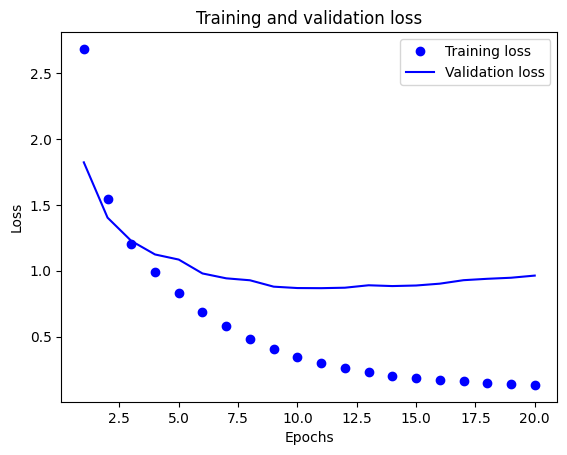

In [43]:
# 繪製訓練和驗證損失圖
import matplotlib.pyplot as plt # 導入 matplotlib.pyplot 模組，用於繪製圖表。

loss = history.history['loss'] # 從訓練歷史物件中取得每個 epoch 的訓練損失值。
val_loss = history.history['val_loss'] # 從訓練歷史物件中取得每個 epoch 的驗證損失值。

epochs = range(1, len(loss) + 1) # 創建一個 epoch 數值的序列，用於 X 軸。

plt.plot(epochs, loss, 'bo', label='Training loss') # 繪製訓練損失曲線，'bo' 表示藍色圓點。
plt.plot(epochs, val_loss, 'b', label='Validation loss') # 繪製驗證損失曲線，'b' 表示藍色實線。
plt.title('Training and validation loss') # 設定圖表的標題。
plt.xlabel('Epochs') # 設定 X 軸標籤。
plt.ylabel('Loss') # 設定 Y 軸標籤。
plt.legend() # 顯示圖例，解釋曲線的含義。

plt.show() # 顯示圖表。

## **【程式4.20】**

最後，繪製其損失以及**準確性**曲線圖

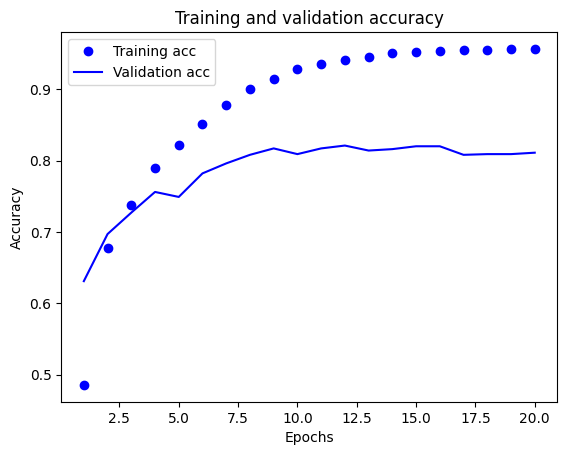

In [44]:
# 繪製訓練和驗證準確性圖

# 先清除畫面
plt.clf() # 清除當前圖表，確保新圖表不會與前一個圖表重疊。
acc = history.history['accuracy'] # 從訓練歷史物件中取得每個 epoch 的訓練準確度值。
val_acc = history.history['val_accuracy'] # 從訓練歷史物件中取得每個 epoch 的驗證準確度值。

plt.plot(epochs, acc, 'bo', label='Training acc') # 繪製訓練準確度曲線，'bo' 表示藍色圓點。
plt.plot(epochs, val_acc, 'b', label='Validation acc') # 繪製驗證準確度曲線，'b' 表示藍色實線。
plt.title('Training and validation accuracy') # 設定圖表的標題。
plt.xlabel('Epochs') # 設定 X 軸標籤。
plt.ylabel('Accuracy') # 設定 Y 軸標籤。
plt.legend() # 顯示圖例，解釋曲線的含義。

plt.show() # 顯示圖表。

## **【程式4.21】**

從頭開始訓練模型

In [45]:
model = keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(partial_x_train, # 全部使用測試資料集
      partial_y_train, # 全部使用測試資料集
      epochs=9, # 訓練9個週期就好，
      batch_size=512, # 並設定批次大小為512。
      validation_data=(x_val, y_val))

results = model.evaluate(x_test, y_test)

Epoch 1/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.3907 - loss: 3.2206 - val_accuracy: 0.5990 - val_loss: 1.8962
Epoch 2/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6509 - loss: 1.6901 - val_accuracy: 0.6920 - val_loss: 1.4272
Epoch 3/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7319 - loss: 1.2432 - val_accuracy: 0.7410 - val_loss: 1.2193
Epoch 4/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7813 - loss: 1.0279 - val_accuracy: 0.7610 - val_loss: 1.1019
Epoch 5/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8235 - loss: 0.8175 - val_accuracy: 0.7760 - val_loss: 1.0238
Epoch 6/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8461 - loss: 0.6939 - val_accuracy: 0.7990 - val_loss: 0.9600
Epoch 7/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.8846 - loss: 0.5605 - val_accuracy: 0.8020 - val_loss: 0.9412
Epoch 8/9
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8984 - loss: 0.4854 - val_accuracy: 0.8110 - val_loss:

In [46]:
results

[0.9432292580604553, 0.7862867116928101]

## **實際問題驗證**

46個類別的樣本分布可能是不平均的，在這種情況下，隨機猜測的準確度有高呢？

In [47]:
import copy
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)
hits_array = np.array(test_labels) == np.array(test_labels_copy)
float(np.sum(hits_array)) / len(test_labels)

0.1861086375779163

輸出為0.18521816562778273。
由此可知，隨機猜測的準確性僅19%左右，遠遠低於我們模型的準確性。
所以，我們的模型表現是相當不錯。

## **對新資料進行預測**

使用predict方法，取得46個主題的機率分布。

In [48]:
# 首先，為測試資料做主題預測
predictions = model.predict(x_test)

# predictions陣列中的每個項目都是長度等於46的向量
predictions[0].shape

# 該向量中的元素總和等於1（機率總和等於1）
np.sum(predictions[0])

# 擁有最大數值的項目就是模型預測該樣本所屬的類別(也就是最高機率的類別)
np.argmax(predictions[0])

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


np.int64(3)

## **處理標籤與損失的另一種方式**

In [49]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [50]:
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## **擁有足夠大型中間層的重要性**

4-2章節的最終輸出是46維，因此，應該要避免使用少於46個單元的中間層。
如果使用了少於46個單元的中間層，將發生怎樣的情況呢？


In [51]:
from tensorflow import keras # 確保 keras 模組已匯入
from tensorflow.keras import layers # 確保 layers 模組已匯入

model = keras.Sequential() # 將 models.Sequential() 修改為 keras.Sequential() 以修正 NameError
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
# 為了測試，故意將中間層改為4個單元
model.add(layers.Dense(4, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))

model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(partial_x_train,
          partial_y_train,
          epochs=20,
          batch_size=128,
          validation_data=(x_val, y_val))

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.3329 - loss: 3.2676 - val_accuracy: 0.6030 - val_loss: 2.0606
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6535 - loss: 1.7806 - val_accuracy: 0.6590 - val_loss: 1.5556
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7040 - loss: 1.3636 - val_accuracy: 0.6850 - val_loss: 1.4187
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7274 - loss: 1.1720 - val_accuracy: 0.6950 - val_loss: 1.3422
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7383 - loss: 1.0774 - val_accuracy: 0.6980 - val_loss: 1.3076
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7505 - loss: 0.9508 - val_accuracy: 0.6980 - val_loss: 1.3047
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7464 - loss: 0.9379 - val_accuracy: 0.6980 - val_loss: 1.3253
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7652 - loss: 0.8539 - val_accuracy: 0.7010 - v